# 04 - Rainfall Simulation Demo

This notebook demonstrates turning Gaussian noise into rainfall using the validated simulation wrapper and bundled fitted distribution parameter files.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from stormlab.simulation import simulate_rainfall

In [2]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
OUTPUT_ROOT = REPO_ROOT / "output" / "examples_pipeline"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data root exists: {DATA_ROOT.exists()}")

Repo root: c:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab
Data root exists: True


In [3]:
ar_id = 202200018
realization = 1
noise_dir = DATA_ROOT / "cesm2" / "cesm2_rainstorm_simulation"
param_dir = DATA_ROOT / "cesm2" / "cesm2_rainstorms_distr_params"

noise_ds = xr.load_dataset(noise_dir / f"{ar_id}_{realization}_noise.nc")
wet_prob_ds = xr.load_dataset(param_dir / f"{ar_id}_logit_wet_p.nc")
gamma_shape_ds = xr.load_dataset(param_dir / f"{ar_id}_scipy_a.nc")
gg_c_ds = xr.load_dataset(param_dir / f"{ar_id}_scipy_c.nc")
gamma_scale_ds = xr.load_dataset(param_dir / f"{ar_id}_scipy_scale.nc")

print(noise_ds)

<xarray.Dataset> Size: 70MB
Dimensions:    (time: 27, latitude: 630, longitude: 1024)
Coordinates:
  * time       (time) <U19 2kB '2022-03-20 06:00:00' ... '2022-03-26 18:00:00'
  * latitude   (latitude) float64 5kB 50.0 49.97 49.93 49.9 ... 29.07 29.03 29.0
  * longitude  (longitude) float64 8kB -113.2 -113.1 -113.1 ... -79.1 -79.07
Data variables:
    aorc       (time, latitude, longitude) float32 70MB 0.03076 ... 0.01658
Attributes:
    description:  Noise field 1 for AORC AR id 202200018


In [4]:
# Use a subset for quick demo plotting.
time_subset = slice(0, 4)
y_subset = slice(240, 368)
x_subset = slice(420, 548)

noise = noise_ds["aorc"].data[time_subset, y_subset, x_subset]
wet_probability = wet_prob_ds["aorc"].data[time_subset, y_subset, x_subset]
gamma_shape = gamma_shape_ds["aorc"].data[time_subset, y_subset, x_subset]
gamma_scale = gamma_scale_ds["aorc"].data[time_subset, y_subset, x_subset]
generalized_gamma_c = gg_c_ds["aorc"].data[y_subset, x_subset]

simulated = simulate_rainfall(
    noise,
    wet_probability,
    gamma_shape,
    gamma_scale,
    generalized_gamma_c,
)

print(f"Simulated rainfall shape: {simulated.shape}")
print(f"Rainfall min/mean/max: {simulated.min():.3f} / {simulated.mean():.3f} / {simulated.max():.3f}")

Simulated rainfall shape: (4, 128, 128)
Rainfall min/mean/max: 0.000 / 0.381 / 16.541


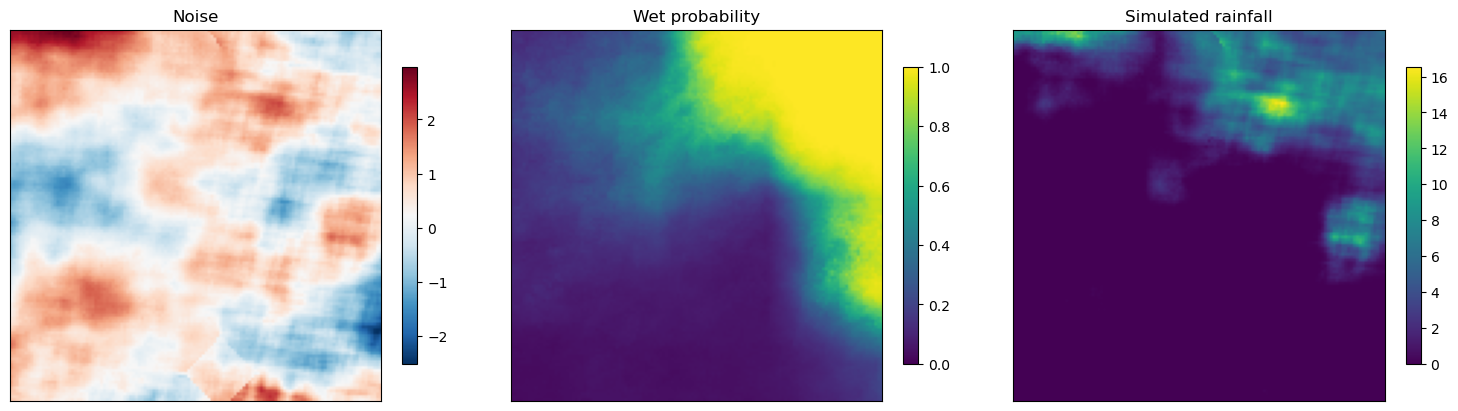

In [5]:
time_index = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(noise[time_index], origin="upper", cmap="RdBu_r")
axes[0].set_title("Noise")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(wet_probability[time_index], origin="upper", vmin=0, vmax=1)
axes[1].set_title("Wet probability")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(simulated[time_index], origin="upper")
axes[2].set_title("Simulated rainfall")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

In [ ]:
# Optional save.
# np.save(OUTPUT_ROOT / "simulated_rainfall_subset.npy", simulated)